# ESRI Land Cover

* **Products used:** 
[io_lulc_annual_v02](http://localhost:81/products/io_lulc_annual_v02)

Notebook modified from https://github.com/opendatacube/cube-in-a-box/blob/main/notebooks/ESRI_Land_Cover.ipynb (based on [io-lulc](https://planetarycomputer.microsoft.com/dataset/io-lulc) (deprecated) and updated for [https://planetarycomputer.microsoft.com/dataset/io-lulc-annual-v02](io-lulc-annual-v02)).

## Background

This dataset, produced by [Impact Observatory](http://impactobservatory.com/), Microsoft, and Esri, displays a global map of land use and land cover (LULC) derived from ESA Sentinel-2 imagery at 10 meter resolution for the years 2017 - 2023. Each map is a composite of LULC predictions for 9 classes throughout the year in order to generate a representative snapshot of each year. This dataset was generated by Impact Observatory, which used billions of human-labeled pixels (curated by the National Geographic Society) to train a deep learning model for land classification. Each global map was produced by applying this model to the Sentinel-2 annual scene collections from the Mircosoft Planetary Computer. Each of the maps has an assessed average accuracy of over 75%.

These maps have been improved from Impact Observatory’s [previous release](https://planetarycomputer.microsoft.com/dataset/io-lulc-9-class) and provide a relative reduction in the amount of anomalous change between classes, particularly between “Bare” and any of the vegetative classes “Trees,” “Crops,” “Flooded Vegetation,” and “Rangeland”. This updated time series of annual global maps is also re-aligned to match the ESA UTM tiling grid for Sentinel-2 imagery.

**Product details:**
* Product name in the datacube: `"io_lulc_annual_v02"`
* `Land Cover` product
* Spatial resolution: 10 m
* Date-range (yearly dataset): 1984 to 2023
* Universal Transverse Mercator (UTM) map projection. World Geodetic System (WGS) 84 datum
* Stored in Cloud-Optimised GeoTIFF Format (COG)

## Description

This notebook will run through loading in io_lulc_annual_v02 Product images.
Topics covered include:

* Using the native `dc.load()` function to load in Land Cover data
* Using local function to plot Land Cover

## Getting started

To run this analysis, run all the cells in the notebook, starting with the "Load packages" cell.

### Load packages

In [1]:
import sys
sys.path.insert(1, '../utils/')

In [2]:
# reload module before executing code
%load_ext autoreload
%autoreload 2

import datacube
import time
import numpy as np
from utils.nostra_dc import get_product_bbox
from utils.nostra_mapping import bbox_to_polygon, display_crosshair, MapHandler
from utils.nostra_plotting import plot_da_categories
from utils.nostra_tools import style_output_cells

from planetary_computer import sign_url  # needed to access planetary-computer collection

### Create a local function

### Connect to the datacube

In [3]:
dc = datacube.Datacube(app='ESRI_Land_Cover')

## Describe product measurements

In [4]:
dc.list_measurements().loc['io_lulc_annual_v02']

,name,dtype,units,nodata,aliases,flags_definition
measurement,,,,,,
data,data,uint8,1,0.0,[classification],"{'data': {'bits': [0, 1, 2, 3, 4, 5, 6, 7], 'v..."


## Load ESRI Land Cover data from the datacube

As this product contains only a single integer band for a limited number of times, and consequently is way lighter than other available products, we will process it the light way, meaning without Daskerization (as in other products notebooks).

In [5]:
# Check if default bbox is contained within the datacube
# and allow user to draw bbox if not.

product = 'io_lulc_annual_v02'

# configure a default bounding box and visualize it
lat, lon = 22.821, 28.518
buffer = 0.1
default_bbox = (lon - buffer, lat - buffer, lon + buffer, lat + buffer)

product_bbox = get_product_bbox(dc, product, split_size=10, stability_threshold=4)

is_contained =(default_bbox[0] >= product_bbox[0] and
               default_bbox[1] >= product_bbox[1] and
               default_bbox[2] <= product_bbox[2] and
               default_bbox[3] <= product_bbox[3]
              )

In [6]:
# Create an instance of MapHandler
map_handler = MapHandler()
m, drc = map_handler.create_map(vect=[bbox_to_polygon(default_bbox), bbox_to_polygon(product_bbox)],
                               draw_rect=True)
display(m)

# append crosshair
time.sleep(2)  # make sure m is fully displayed
display_crosshair()

Map(center=[24.007210416068155, 30.0], controls=(AttributionControl(options=['position', 'prefix'], position='…

<IPython.core.display.Javascript object>

In [7]:
# Warn in case of full AoI
aoi_poly = map_handler.aoi_tupple

if aoi_poly is None:
    aoi_poly = tuple(default_bbox)
    if not is_contained:
        style_output_cells('salmon', border_color='red', border_width='2px')
        print('The area of interest polygon is located outside of the product extent.' + \
              '\nPlease draw a new area of interest in the previous cell.')
    else:
        # When is_contained is True and no polygon drawn - this is actually OK!
        style_output_cells()
        print('Default area of interest is contained within the product extent, but you can still draw another one in the previous cell.')
else:
    # A polygon was drawn
    style_output_cells()
    print('Custom area of interest polygon has been created.')

Default area of interest is contained within the product extent, but you can still draw another one in the previous cell.


In [8]:
# Create a query object (we don't need to define time range and measurements as it is a
# single time and single band product) and use it to load the data

query = {
    'product': product,
    'x': (aoi_poly[0], aoi_poly[2]),
    'y': (aoi_poly[1], aoi_poly[3]),
    'output_crs': 'epsg:6933',
    'resolution':30,
    'patch_url': sign_url,
}

ds = dc.load(**query)
print(ds)

<xarray.Dataset> Size: 4MB
Dimensions:      (time: 7, y: 787, x: 644)
Coordinates:
  * time         (time) datetime64[ns] 56B 2017-07-02T12:00:00 ... 2023-07-02...
  * y            (y) float64 6kB 2.849e+06 2.849e+06 ... 2.825e+06 2.825e+06
  * x            (x) float64 5kB 2.742e+06 2.742e+06 ... 2.761e+06 2.761e+06
    spatial_ref  int32 4B 6933
Data variables:
    data         (time, y, x) uint8 4MB 8 8 8 8 8 8 8 8 8 ... 5 5 5 5 5 5 8 8 8
Attributes:
    crs:           EPSG:6933
    grid_mapping:  spatial_ref


## Plot ESRI  Land Cover

To do so you need to first define the style of each Land Cover category

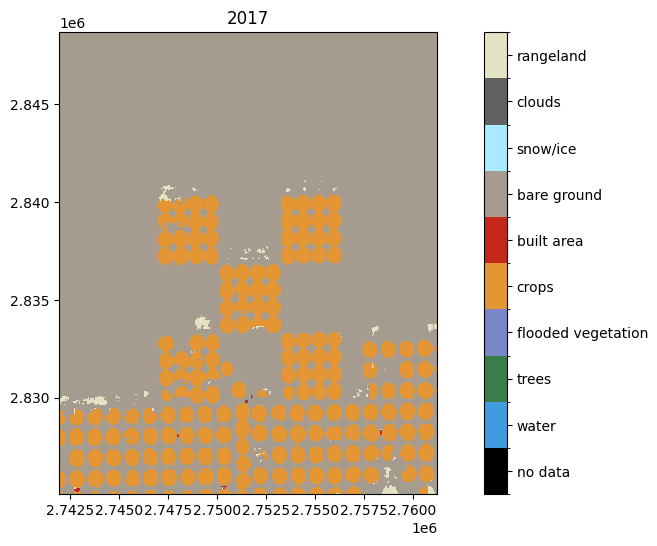

In [9]:
# Plot the first time

# define Value, Color and Label triplets
vcls = [
    (0, (0, 0, 0), 'no data'),
    (1, (65, 155, 223), 'water'),
    (2, (57, 125, 73), 'trees'),
    (4, (122, 135, 198), 'flooded vegetation'),
    (5, (228, 150, 53), 'crops'),
    (7, (196, 40, 27), 'built area'),
    (8, (165, 155, 143), 'bare ground'),
    (9, (168, 235, 255), 'snow/ice'),
    (10, (97, 97, 97), 'clouds'),
    (11, (227, 226, 195), 'rangeland')
]

da = ds["data"].isel(time=0)
plot_da_categories(da, vcls, title= da.time.values.astype('datetime64[Y]').astype(int) + 1970,
                   cb=True, figsize=(12, 6))

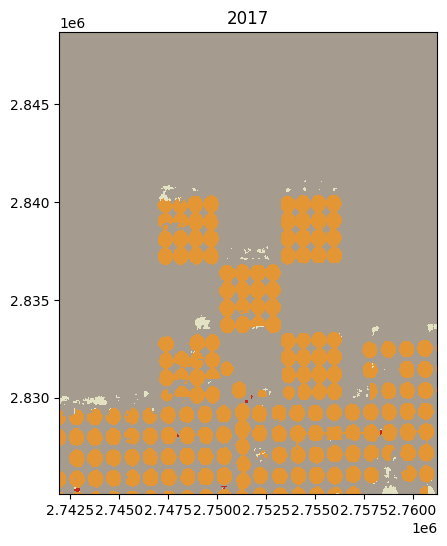

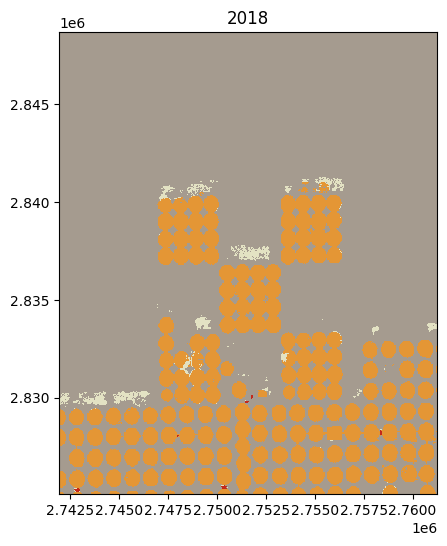

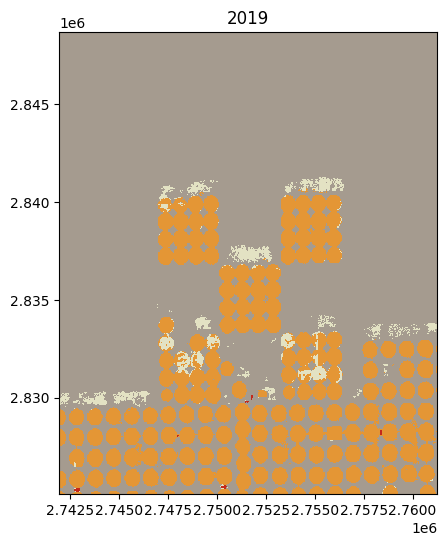

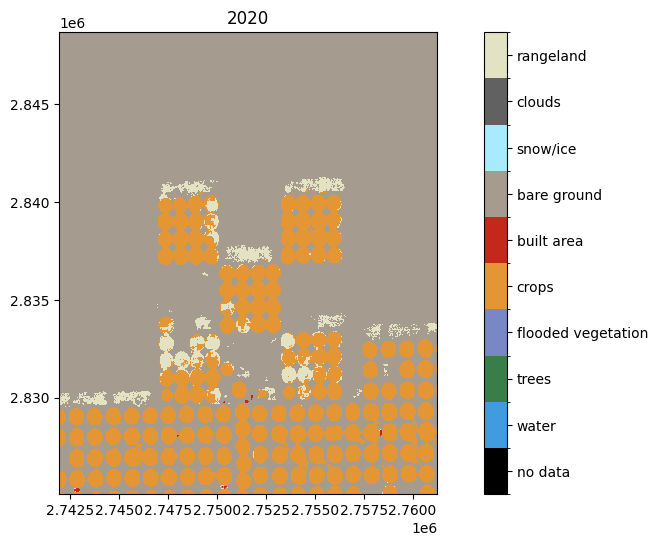

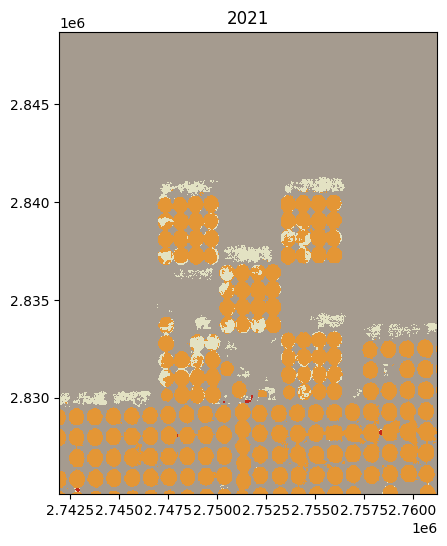

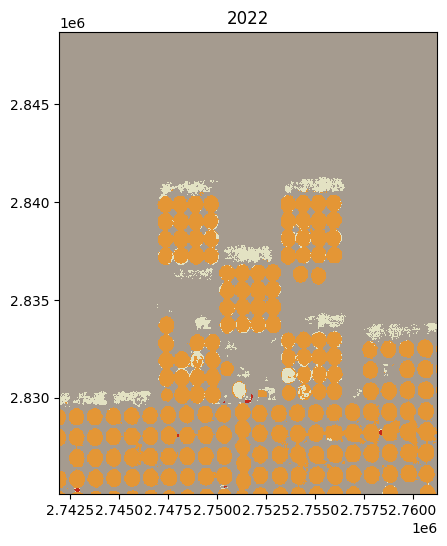

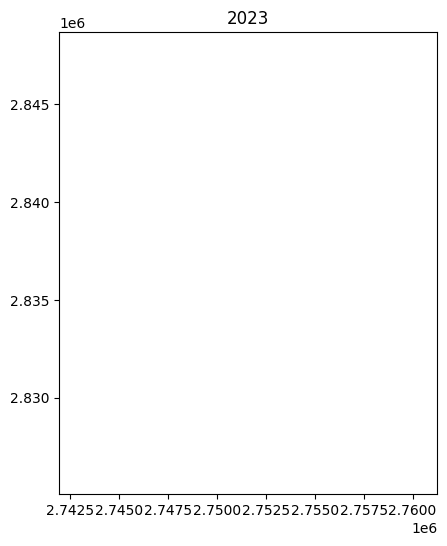

In [10]:
# Plot all time, displaying a colorbar only midway

for idx in range(len(ds.time)):
    da = ds["data"].isel(time=idx)
    cb = idx == np.floor(len(ds.time) / 2)  # display colorbar midway
    plot_da_categories(da, vcls, title= da.time.values.astype('datetime64[Y]').astype(int) + 1970,
                       cb=cb, figsize=(12, 6))

***

## Additional information

**License:** The code in this notebook is slighly modified from https://github.com/digitalearthafrica/deafrica-sandbox-notebooks and licensed under the [Apache License, Version 2.0](https://www.apache.org/licenses/LICENSE-2.0).

**Compatible datacube version:**

In [11]:
print(datacube.__version__)

1.9.12


In [12]:
from datetime import datetime
datetime.today().strftime('%Y-%m-%d')

'2026-01-09'

In [13]:
!pip freeze

affine==2.4.0
ai-edge-litert==2.1.0
aiobotocore==3.1.0
aiohappyeyeballs==2.6.1
aiohttp==3.13.3
aioitertools==0.13.0
aiosignal==1.4.0
alembic==1.17.2
annotated-types==0.7.0
antimeridian==0.4.4
anyio==4.12.1
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
arrow==1.4.0
asttokens==3.0.1
async-lru==2.0.5
attrs==25.4.0
babel==2.17.0
backports.strenum==1.2.8
beautifulsoup4==4.14.3
bleach==6.3.0
bokeh==3.8.2
boltons==25.0.0
boto3==1.42.19
botocore==1.42.19
branca==0.8.2
cachetools==6.2.4
cattrs==25.3.0
certifi==2026.1.4
cffi==2.0.0
cftime==1.6.5
charset-normalizer==3.4.4
ciso8601==2.3.3
click==8.1.8
click-plugins==1.1.1.2
cligj==0.7.2
cloudpickle==3.1.2
comm==0.2.3
contourpy==1.3.3
cycler==0.12.1
dask==2025.7.0
dask-image==2025.11.0
dask_labextension==7.0.0
datacube==1.9.12
datadog==0.52.1
debugpy==1.8.19
decorator==5.2.1
defusedxml==0.7.1
deprecat==2.1.3
distributed==2025.7.0
eodatasets3==1.9.3
executing==2.2.1
fastjsonschema==2.21.2
fiona==1.10.1
flatbuffers==25.12.19
folium==0.20.0
fonttoo